# 인구 유입 및 정착에 영향을 주는 요인 분석을 통한 맞춤형 정책 제안

In [3]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


In [2]:
import folium
import geopandas as gpd
import pandas as pd
import numpy as np
import glob
import os

In [2]:
df = pd.read_csv(r"C:/Users/THKIM/Desktop/3-1 프로젝트/영천시 공공 데이터 공모전/데이터 셋/dataset/영천시_통합_마스터(변수추가).csv")

# 1.문제 정의 및 가설 수립
### 인구가 감소하는 주요 원인은 무엇인가?
### 어떤 읍면동은 청년층 비율이 높고, 어떤 곳은 낮은가?
#### 복지·문화 인프라가 풍부할수록 전입률이 높고 인구 유입이 많다.
#### 의료 접근성이 좋을수록 노인층이 많은 지역에 정착한다.
#### 청년층은 문화시설과 일자리(사업체·종사자수)에 반응한다.

# 2. 탐색적 분석 및 시각화

## 2-1. 읍면동별 청년인구비율 분포 시각화

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows 기준 '맑은 고딕' 사용)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

C:\Users\THKIM\AppData\Local\Temp\ipykernel_9200\2831722406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_df, x='행정동', y='청년인구비율(%)', palette='Blues_d')


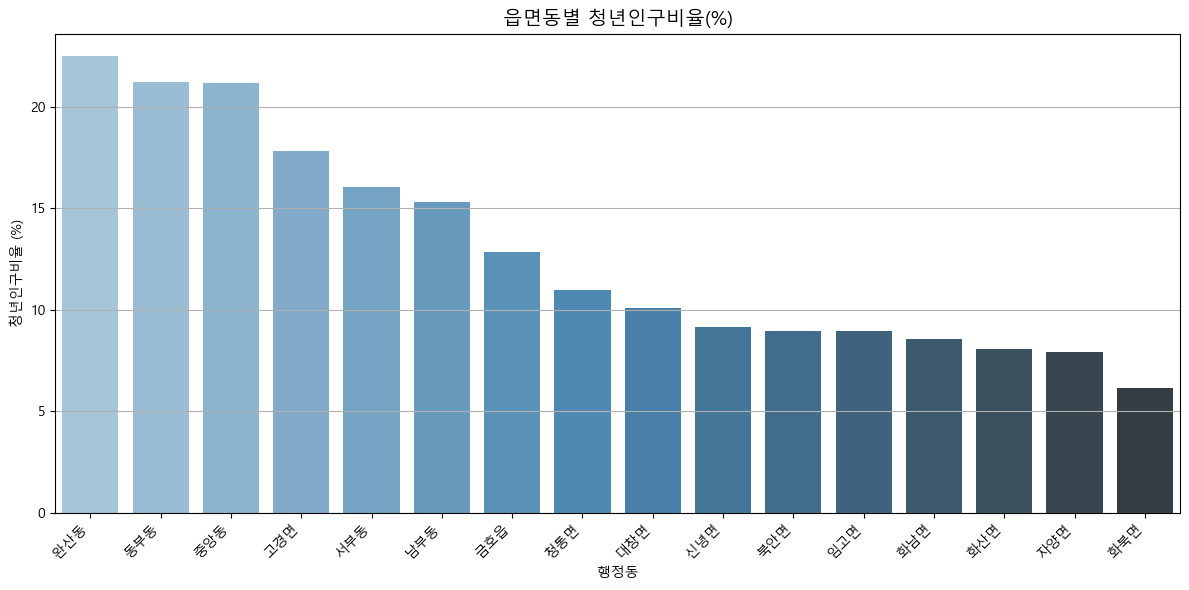

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 청년인구비율 기준 정렬
sorted_df = df.sort_values(by='청년인구비율(%)', ascending=False)

# 시각화
plt.figure(figsize=(12,6))
sns.barplot(data=sorted_df, x='행정동', y='청년인구비율(%)', palette='Blues_d')

plt.xticks(rotation=45, ha='right')
plt.title("읍면동별 청년인구비율(%)", fontsize=14)
plt.xlabel("행정동")
plt.ylabel("청년인구비율 (%)")
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

## 2-2. 청년인구비율 상위/하위 읍면동 Top 5

In [6]:
# 청년층 비율이 높은 읍면동 상위 5개
top5 = df[['행정동', '청년인구비율(%)']].sort_values(by='청년인구비율(%)', ascending=False).head(5)

# 청년층 비율이 낮은 읍면동 하위 5개
bottom5 = df[['행정동', '청년인구비율(%)']].sort_values(by='청년인구비율(%)', ascending=True).head(5)

print("✅ 청년인구비율 높은 읍면동 Top 5:")
display(top5)

print("✅ 청년인구비율 낮은 읍면동 Bottom 5:")
display(bottom5)

✅ 청년인구비율 높은 읍면동 Top 5:


,행정동,청년인구비율(%)
8,완산동,22.49
4,동부동,21.23
11,중앙동,21.19
0,고경면,17.83
6,서부동,16.03


✅ 청년인구비율 낮은 읍면동 Bottom 5:


,행정동,청년인구비율(%)
14,화북면,6.15
10,자양면,7.94
15,화산면,8.09
13,화남면,8.57
9,임고면,8.94


## 2-3. 청년인구비율과 전입률 관계 시각화

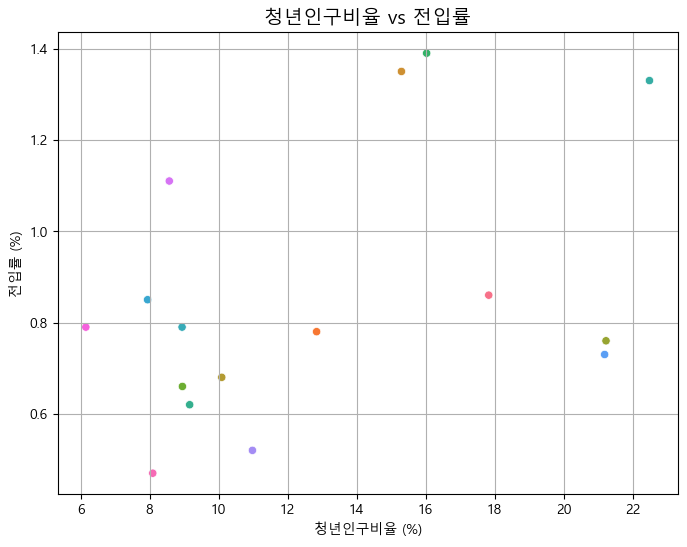

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='청년인구비율(%)', y='전입률(%)', hue='행정동', legend=False)
plt.title("청년인구비율 vs 전입률", fontsize=14)
plt.xlabel("청년인구비율 (%)")
plt.ylabel("전입률 (%)")
plt.grid(True)
plt.show()

# 3. 모델 기반 변수 중요도 분석

## 분석 1: ElasticNet 기반 변수 중요도 분석 (총인구 기준)

In [2]:
pip install scikit-learn


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------------------------ --------------- 6.8/11.1 MB 42.0 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 43.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


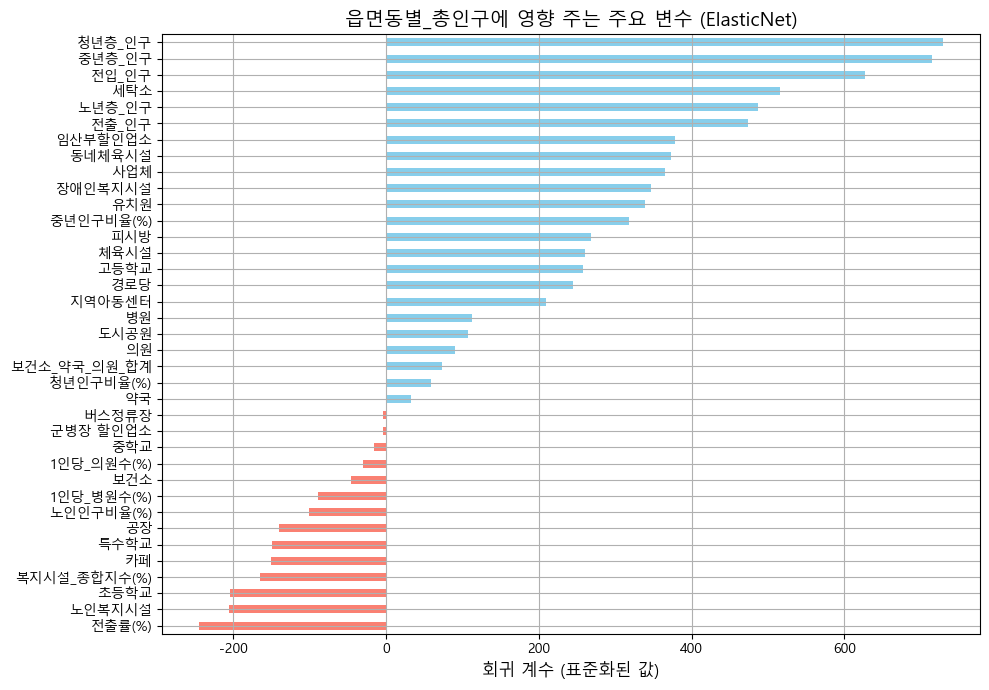

✅ R²: 0.9997
✅ MAE: 80.09명
✅ RMSE: 106.74명
✅ 최적 l1_ratio: 0.99, alpha: 5.874146018002072


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (예: 'Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


# 1. 독립변수(X)와 종속변수(y) 분리
X = df.drop(columns=['행정동', '읍면동별_총인구'])  # 비수치형 또는 종속변수 제외
y = df['읍면동별_총인구']

# 2. 스케일링 (표준화)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. ElasticNetCV 모델 학습 (5-폴드 교차검증, 다양한 l1_ratio 시도)
elastic = ElasticNetCV(cv=5, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], random_state=42)
elastic.fit(X_scaled, y)

# 4. 변수 중요도 도출
elastic_coef = pd.Series(elastic.coef_, index=X.columns)
important_vars = elastic_coef[elastic_coef != 0].sort_values()

# 5. 시각화
colors = ['skyblue' if val > 0 else 'salmon' for val in important_vars]

plt.figure(figsize=(10,7))
important_vars.plot(kind='barh', color=colors)
plt.title('읍면동별_총인구에 영향 주는 주요 변수 (ElasticNet)', fontsize=14)
plt.xlabel('회귀 계수 (표준화된 값)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. 성능 지표 출력
y_pred = elastic.predict(X_scaled)
print(f"✅ R²: {r2_score(y, y_pred):.4f}")
print(f"✅ MAE: {mean_absolute_error(y, y_pred):.2f}명")
print(f"✅ RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f}명")
print(f"✅ 최적 l1_ratio: {elastic.l1_ratio_}, alpha: {elastic.alpha_}")

In [8]:
from sklearn.model_selection import cross_val_score

# R² (기본 scoring)
scores = cross_val_score(elastic, X_scaled, y, cv=5, scoring='r2')
print(f"✅ 교차검증 R² 평균: {scores.mean():.4f}, 표준편차: {scores.std():.4f}")

c:\Users\THKIM\anaconda3\envs\py11gpu\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.935e+05, tolerance: 5.178e+04
  model = cd_fast.enet_coordinate_descent(


✅ 교차검증 R² 평균: 0.7476, 표준편차: 0.2109


c:\Users\THKIM\anaconda3\envs\py11gpu\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.487e+05, tolerance: 5.010e+04
  model = cd_fast.enet_coordinate_descent(


## 분석 2: ElasticNet 기반 변수 중요도 분석 (청년층_인구 기준)

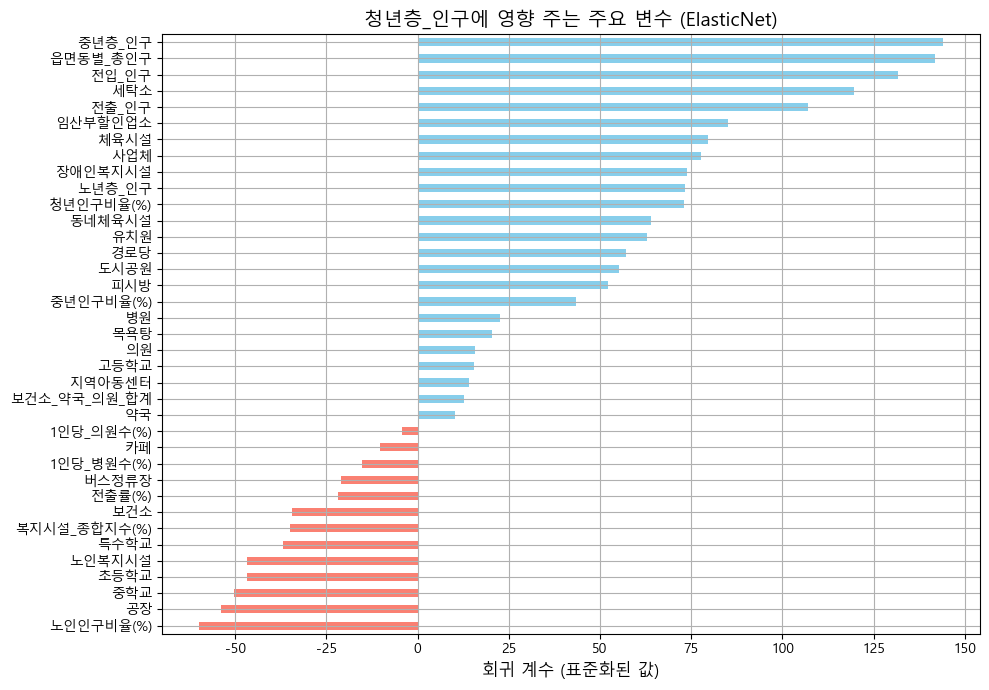

✅ R²: 0.9917
✅ MAE: 96.69명
✅ RMSE: 121.58명
✅ 최적 l1_ratio: 0.95, alpha: 5.9898676214726905


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. 독립변수(X)와 종속변수(y) 분리
X = df.drop(columns=['행정동', '청년층_인구'])  # 비수치형 또는 종속변수 제외
y = df['청년층_인구']

# 2. 스케일링 (표준화)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. ElasticNetCV 모델 학습 (5-폴드 교차검증, 다양한 l1_ratio 시도)
elastic = ElasticNetCV(cv=5, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], random_state=42)
elastic.fit(X_scaled, y)

# 4. 변수 중요도 도출
elastic_coef = pd.Series(elastic.coef_, index=X.columns)
important_vars = elastic_coef[elastic_coef != 0].sort_values()

# 5. 시각화
colors = ['skyblue' if val > 0 else 'salmon' for val in important_vars]

plt.figure(figsize=(10,7))
important_vars.plot(kind='barh', color=colors)
plt.title('청년층_인구에 영향 주는 주요 변수 (ElasticNet)', fontsize=14)
plt.xlabel('회귀 계수 (표준화된 값)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. 성능 지표 출력
y_pred = elastic.predict(X_scaled)
print(f"✅ R²: {r2_score(y, y_pred):.4f}")
print(f"✅ MAE: {mean_absolute_error(y, y_pred):.2f}명")
print(f"✅ RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f}명")
print(f"✅ 최적 l1_ratio: {elastic.l1_ratio_}, alpha: {elastic.alpha_}")

##### R²	설명력 (0~1 사이, 클수록 좋음)	↑
##### MAE	평균 오차 크기 (작을수록 좋음)	↓
##### RMSE	큰 오차에 민감한 평균 오차	↓
##### l1_ratio	L1 vs L2 규제 비율	(문제에 따라 다름)
##### alpha	규제 세기 (높을수록 더 강하게 계수 줄임)	(최적값 자동 탐색됨)

In [11]:
pip install kneed


Note: you may need to restart the kernel to use updated packages.


✅ 엘보우로 찾은 후보 k: 4
✅ 실루엣 점수로 찾은 최적 k: 2


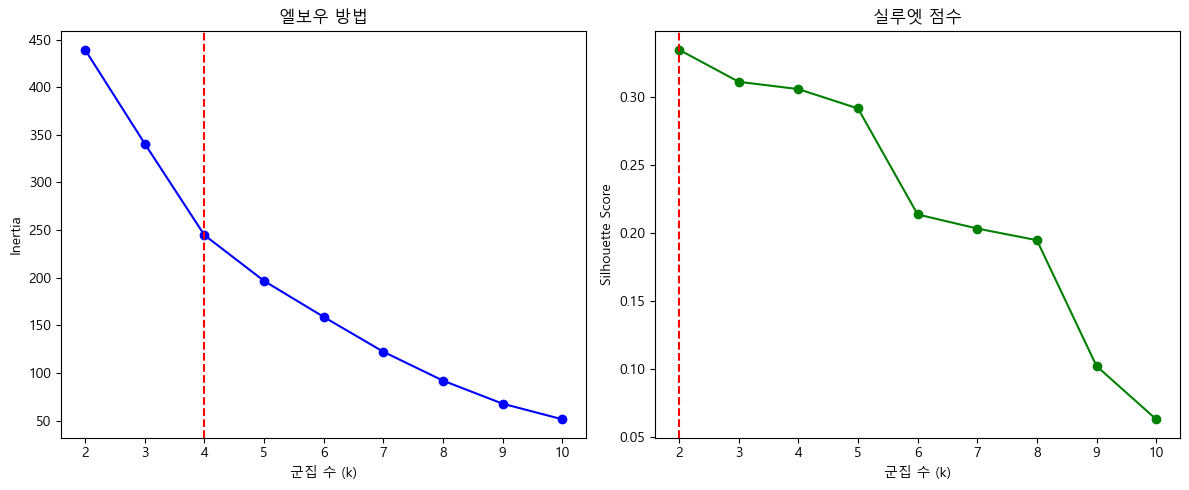

In [12]:
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

# 2. 군집 대상 변수만 선택
X = df.drop(columns=['행정동', '읍면동별_총인구'])

# 3. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 여러 k값 테스트
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 5. 엘보우로 1차 후보 선정
knee = KneeLocator(K_range, inertia, curve='convex', direction='decreasing')
elbow_k = knee.knee
print(f"✅ 엘보우로 찾은 후보 k: {elbow_k}")

# 6. 실루엣 점수 최고점 k 찾기
best_silhouette_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"✅ 실루엣 점수로 찾은 최적 k: {best_silhouette_k}")

# 7. 그래프 그리기
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Inertia (엘보우)
ax[0].plot(K_range, inertia, 'bo-')
ax[0].axvline(elbow_k, color='red', linestyle='--')
ax[0].set_xlabel('군집 수 (k)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('엘보우 방법')

# Silhouette
ax[1].plot(K_range, silhouette_scores, 'go-')
ax[1].axvline(best_silhouette_k, color='red', linestyle='--')
ax[1].set_xlabel('군집 수 (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('실루엣 점수')

plt.tight_layout()
plt.show()

,청년인구비율(%),전입률(%),전출률(%)
cluster,,,
0,9.67,0.74,0.76
1,14.72,1.17,1.24
2,21.23,0.76,0.88
3,22.49,1.33,1.09
4,21.19,0.73,1.41


<Figure size 1000x600 with 0 Axes>

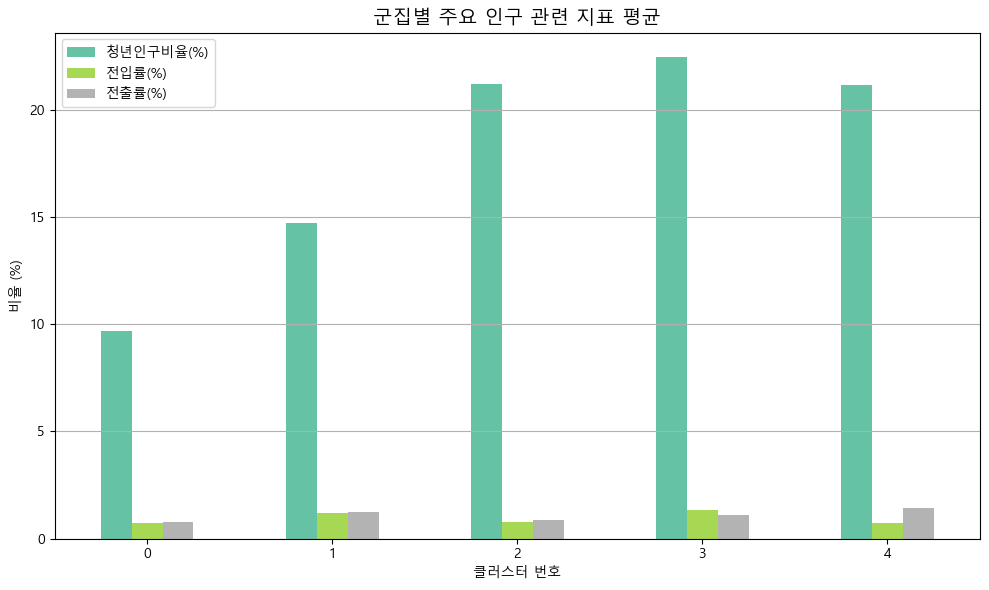

'✅ 각 군집별 읍면동 수:'

cluster
0    10
1     3
2     1
3     1
4     1
Name: count, dtype: int64

In [13]:
# K=5로 최종 군집화
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

import seaborn as sns
import matplotlib.pyplot as plt

# 주요 변수 요약
summary = df.groupby('cluster')[['청년인구비율(%)', '전입률(%)', '전출률(%)']].mean().round(2)
display(summary)

# 시각화
plt.figure(figsize=(10, 6))
summary.plot(kind='bar', colormap='Set2', figsize=(10, 6))
plt.title("군집별 주요 인구 관련 지표 평균", fontsize=14)
plt.ylabel("비율 (%)")
plt.xlabel("클러스터 번호")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

cluster_counts = df['cluster'].value_counts().sort_index()
display("✅ 각 군집별 읍면동 수:")
display(cluster_counts)

In [15]:
import pandas as pd
import geopandas as gpd
import folium
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
shp_path = r"C:/Users/THKIM/Desktop/3-1 프로젝트/영천시 공공 데이터 공모전/데이터 셋/영천시 경계/영천시_읍면동_경계/영천시_행정동_통합경계.shp"

gdf_boundary = gpd.read_file(shp_path).to_crs(epsg=4326)

# 2. 클러스터링 데이터 준비
X = df.drop(columns=['행정동', '읍면동별_총인구'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. KMeans 클러스터링 (k=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['클러스터'] = kmeans.fit_predict(X_scaled)

# 4. 경계파일과 병합 (행정동 기준)
gdf = gdf_boundary.merge(df[['행정동', '클러스터']], how='left', on='행정동')

# 5. 지도 생성
center = gdf.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=11)

# 6. 색깔 매핑
colors = ['red', 'blue', 'green', 'orange','pink']  # 클러스터별 색상

# 7. GeoJson 레이어 추가 (클러스터별 색)
def style_function(feature):
    cluster = feature['properties']['클러스터']
    return {
        'fillColor': colors[cluster] if cluster is not None else 'gray',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6,
    }

folium.GeoJson(
    gdf,
    name="영천시 클러스터링 결과",
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['행정동', '클러스터'],
        aliases=['행정동명', '클러스터'],
        localize=True
    )
).add_to(m)

# 8. 레이어컨트롤 추가
folium.LayerControl(collapsed=False).add_to(m)

# 9. 지도 출력
m

C:\Users\THKIM\AppData\Local\Temp\ipykernel_4744\1085502333.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = gdf.geometry.centroid.unary_union.centroid
C:\Users\THKIM\AppData\Local\Temp\ipykernel_4744\1085502333.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf.geometry.centroid.unary_union.centroid


✅ 로지스틱 회귀 계수 (청년 유입 시급도에 미치는 영향):


임산부할인업소        -0.617637
청년인구비율(%)      -0.549387
공장             -0.425537
목욕탕            -0.392038
버스정류장          -0.359812
노인복지시설         -0.317887
초등학교           -0.317887
중학교            -0.282846
사업체            -0.277246
전출률(%)         -0.271488
도시공원           -0.220147
전출_인구          -0.183019
1인당_병원수(%)     -0.155118
체육시설           -0.154998
전입_인구          -0.150264
중년인구비율(%)      -0.137923
지역아동센터         -0.135521
복지시설_종합지수(%)   -0.128755
노년층_인구         -0.125571
읍면동별_총인구       -0.123805
유치원            -0.114635
중년층_인구         -0.110390
병원             -0.100688
경로당            -0.089162
약국             -0.087457
의원             -0.078808
보건소_약국_의원_합계   -0.077203
카페             -0.066489
1인당_의원수(%)     -0.056459
피시방            -0.018305
세탁소             0.023516
고등학교            0.033809
동네체육시설          0.055539
보건소             0.114385
장애인복지시설         0.189331
특수학교            0.350677
노인인구비율(%)       0.374395
dtype: float64

✅ 청년 유입 시급 TOP 10 읍면동:


,행정동,청년층_인구,청년유입_시급_점수
10,자양면,103,5.024172
14,화북면,133,4.348160
15,화산면,241,3.543394
9,임고면,363,3.231797
3,대창면,298,3.227255
7,신녕면,327,2.948105
5,북안면,381,2.839383
13,화남면,270,2.351574
12,청통면,426,-1.021712
0,고경면,995,-1.130924


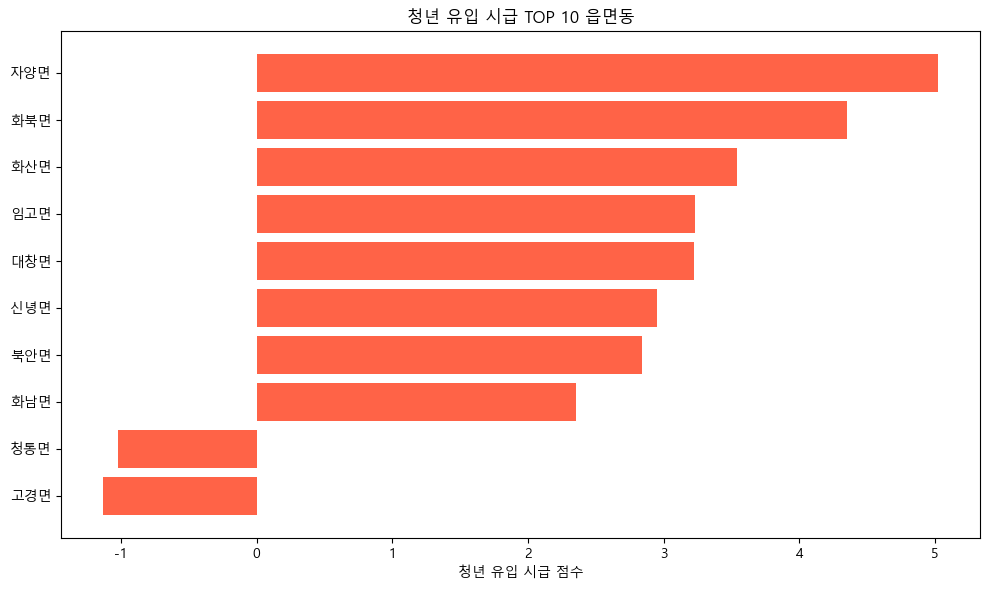

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# 1. 중요 변수만 추출
selected_features = important_vars.index.tolist()
X = df[selected_features]

# 2. 타깃 변수 생성: 청년층_인구가 중앙값보다 작은 지역 = 유입 시급
threshold = df['청년층_인구'].median()
df['청년유입_시급'] = (df['청년층_인구'] < threshold).astype(int)
y = df['청년유입_시급']

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_scaled, y)

# 5. 회귀 계수 확인
coefs = pd.Series(model.coef_[0], index=selected_features)
print("✅ 로지스틱 회귀 계수 (청년 유입 시급도에 미치는 영향):")
display(coefs.sort_values())

# 6. 점수 계산: 가중합
df['청년유입_시급_점수'] = X_scaled.dot(model.coef_[0])

# 7. 점수 기반 정렬
ranked = df[['행정동', '청년층_인구', '청년유입_시급_점수']].sort_values(by='청년유입_시급_점수', ascending=False)

print("✅ 청년 유입 시급 TOP 10 읍면동:")
display(ranked.head(10))

# 8. 시각화 (TOP10)
plt.figure(figsize=(10, 6))
plt.barh(ranked.head(10)['행정동'][::-1], ranked.head(10)['청년유입_시급_점수'][::-1], color='tomato')
plt.xlabel('청년 유입 시급 점수')
plt.title('청년 유입 시급 TOP 10 읍면동')
plt.tight_layout()
plt.show()


✅ 로지스틱 회귀 계수 (청년 유입 시급도에 미치는 영향):


임산부할인업소        -0.617637
청년인구비율(%)      -0.549387
공장             -0.425537
목욕탕            -0.392038
버스정류장          -0.359812
노인복지시설         -0.317887
초등학교           -0.317887
중학교            -0.282846
사업체            -0.277246
전출률(%)         -0.271488
도시공원           -0.220147
전출_인구          -0.183019
1인당_병원수(%)     -0.155118
체육시설           -0.154998
전입_인구          -0.150264
중년인구비율(%)      -0.137923
지역아동센터         -0.135521
복지시설_종합지수(%)   -0.128755
노년층_인구         -0.125571
읍면동별_총인구       -0.123805
유치원            -0.114635
중년층_인구         -0.110390
병원             -0.100688
경로당            -0.089162
약국             -0.087457
의원             -0.078808
보건소_약국_의원_합계   -0.077203
카페             -0.066489
1인당_의원수(%)     -0.056459
피시방            -0.018305
세탁소             0.023516
고등학교            0.033809
동네체육시설          0.055539
보건소             0.114385
장애인복지시설         0.189331
특수학교            0.350677
노인인구비율(%)       0.374395
dtype: float64

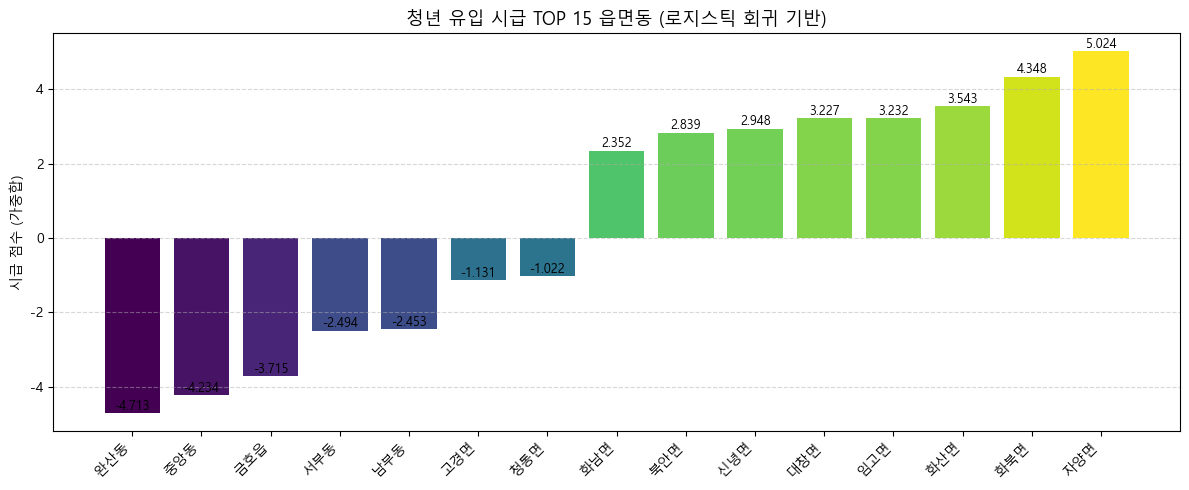

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# 1. 중요 변수만 추출
selected_features = important_vars.index.tolist()
X = df[selected_features]

# 2. 타깃 변수 생성: 청년층_인구가 중앙값보다 작은 지역 = 유입 시급
threshold = df['청년층_인구'].median()
df['청년유입_시급'] = (df['청년층_인구'] < threshold).astype(int)
y = df['청년유입_시급']

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_scaled, y)

# 5. 회귀 계수 확인
coefs = pd.Series(model.coef_[0], index=selected_features)
print("✅ 로지스틱 회귀 계수 (청년 유입 시급도에 미치는 영향):")
display(coefs.sort_values())

# 6. 점수 계산: 가중합
df['청년유입_시급_점수'] = X_scaled.dot(model.coef_[0])

# 7. 점수 기반 정렬
ranked = df[['행정동', '청년층_인구', '청년유입_시급_점수']].sort_values(by='청년유입_시급_점수', ascending=False)

# 8. 시각화 (상위 15개 읍면동)
top_n = 15
top = ranked.head(top_n).copy()
top = top.sort_values(by='청년유입_시급_점수', ascending=True)  # 점수 낮은 게 왼쪽

# 색상 설정 (viridis 그라데이션)
norm = mcolors.Normalize(vmin=top['청년유입_시급_점수'].min(), vmax=top['청년유입_시급_점수'].max())
cmap = cm.viridis
colors = cmap(norm(top['청년유입_시급_점수']))

# 시각화
plt.figure(figsize=(12, 5))
bars = plt.bar(top['행정동'], top['청년유입_시급_점수'], color=colors)

# 텍스트 추가
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f"{height:.3f}", ha='center', va='bottom', fontsize=9)

# 그래프 꾸미기
plt.title("청년 유입 시급 TOP 15 읍면동 (로지스틱 회귀 기반)", fontsize=13)
plt.ylabel("시급 점수 (가중합)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


✅ 로지스틱 회귀 계수 (청년 유입 시급도에 미치는 영향):


임산부할인업소        -0.482817
카페             -0.444501
버스정류장          -0.394669
동네체육시설         -0.391587
사업체            -0.386461
초등학교           -0.304356
노인복지시설         -0.304356
복지시설_종합지수(%)   -0.304341
노년층_인구         -0.272898
청년인구비율(%)      -0.263339
유치원            -0.260457
읍면동별_총인구       -0.252911
중년층_인구         -0.234561
전입_인구          -0.233628
장애인복지시설        -0.206253
목욕탕            -0.205290
체육시설           -0.201481
보건소            -0.164031
특수학교           -0.162808
전출_인구          -0.157526
공장             -0.145575
경로당            -0.143540
도시공원           -0.142624
중년인구비율(%)      -0.118176
보건소_약국_의원_합계   -0.090591
의원             -0.081023
병원             -0.074951
1인당_병원수(%)     -0.068775
지역아동센터         -0.042182
약국              0.014794
전출률(%)          0.034966
1인당_의원수(%)      0.035105
중학교             0.070563
피시방             0.078387
고등학교            0.157083
노인인구비율(%)       0.204599
세탁소             0.267425
dtype: float64

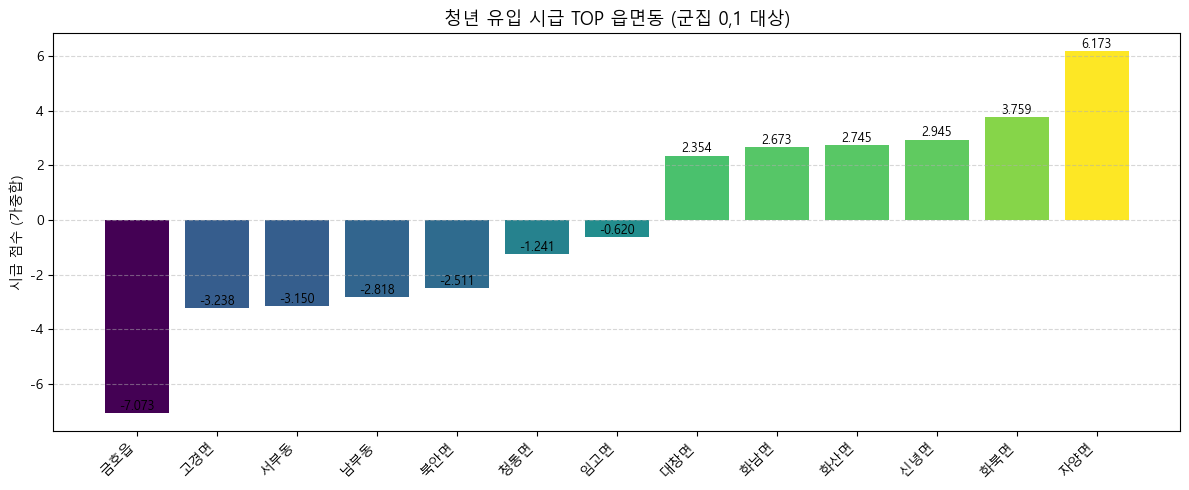

In [18]:
# 0. 군집 0, 1 대상 필터링
target_df = df[df['cluster'].isin([0, 1])].copy()

# 1. 중요 변수만 추출
selected_features = important_vars.index.tolist()
X = target_df[selected_features]

# 2. 타깃 변수 생성: 청년층_인구 중앙값 기준으로 시급 여부 판단
threshold = target_df['청년층_인구'].median()
target_df['청년유입_시급'] = (target_df['청년층_인구'] < threshold).astype(int)
y = target_df['청년유입_시급']

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_scaled, y)

# 5. 회귀 계수 확인
coefs = pd.Series(model.coef_[0], index=selected_features)
print("✅ 로지스틱 회귀 계수 (청년 유입 시급도에 미치는 영향):")
display(coefs.sort_values())

# 6. 점수 계산: 가중합
target_df['청년유입_시급_점수'] = X_scaled.dot(model.coef_[0])

# 7. 점수 기반 정렬
ranked = target_df[['행정동', '청년층_인구', '청년유입_시급_점수']].sort_values(
    by='청년유입_시급_점수', ascending=False
)

# 8. 시각화 (상위 15개 읍면동)
top_n = min(15, len(ranked))  # 15개보다 적을 수도 있으니 예외 처리
top = ranked.head(top_n).copy()
top = top.sort_values(by='청년유입_시급_점수', ascending=True)

# 색상 설정 (viridis)
norm = mcolors.Normalize(vmin=top['청년유입_시급_점수'].min(), vmax=top['청년유입_시급_점수'].max())
cmap = cm.viridis
colors = cmap(norm(top['청년유입_시급_점수']))

# 시각화
plt.figure(figsize=(12, 5))
bars = plt.bar(top['행정동'], top['청년유입_시급_점수'], color=colors)

# 텍스트 추가
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f"{height:.3f}", ha='center', va='bottom', fontsize=9)

plt.title("청년 유입 시급 TOP 읍면동 (군집 0,1 대상)", fontsize=13)
plt.ylabel("시급 점수 (가중합)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [19]:
# 청년 유입 시급 Top 3 읍면동 추출
top3_names = ['자양면', '화북면', '신녕면']
top3_df = target_df[target_df['행정동'].isin(top3_names)].copy()

# 결과 확인
print("✅ 청년 유입 시급 Top 3 읍면동:")
display(top3_df)

✅ 청년 유입 시급 Top 3 읍면동:


,행정동,노년층_인구,공장,보건소,사업체,종사자수(명),약국,영화관,경로당,고등학교,...,보건소_약국_의원_합계,학교_시설_합계,문화시설_합계,복지시설_종합지수(%),1인당_의원수(%),1인당_병원수(%),cluster,클러스터,청년유입_시급,청년유입_시급_점수
7,신녕면,1766,24,2,592,1460,3,0,27,1,...,12,3,6,0.0,0.20,0.14,0,0,1,2.945229
10,자양면,618,0,2,91,158,0,0,19,0,...,4,0,0,0.0,0.15,0.00,0,0,1,6.173246
14,화북면,1106,4,2,495,728,0,0,20,0,...,4,1,4,0.0,0.09,0.00,0,0,1,3.759261


In [20]:
import geopandas as gpd
import folium

# 1. SHP 파일 불러오기 (전체 읍면동 경계)
shp_path = r"C:/Users/THKIM/Desktop/3-1 프로젝트/영천시 공공 데이터 공모전/데이터 셋/영천시 경계/영천시_읍면동_경계/영천시_행정동_통합경계.shp"
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)

# 2. Top3 읍면동 리스트
highlight_names = ['자양면', '화북면', '신녕면']

# 3. 지도 생성 (중심좌표 자동 계산)
center = gdf.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=11)

# 4. 전체 읍면동 경계 그리기
folium.GeoJson(
    gdf,
    name="전체 읍면동",
    style_function=lambda feature: {
        'fillColor': 'white',
        'color': 'gray',
        'weight': 1,
        'fillOpacity': 0.1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['행정동'],
        aliases=['읍면동'],
        localize=True
    )
).add_to(m)

# 5. 자양면·화북면·신녕면 강조
highlight_gdf = gdf[gdf['행정동'].isin(highlight_names)]

folium.GeoJson(
    highlight_gdf,
    name="청년유입 시급 Top 3",
    style_function=lambda feature: {
        'fillColor': 'crimson',
        'color': 'darkred',
        'weight': 2,
        'fillOpacity': 0.5
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['행정동'],
        aliases=['🏁 청년 유입 시급 읍면동']
    )
).add_to(m)

# 6. 마커 추가 (중심 위치에 라벨)
for _, row in highlight_gdf.iterrows():
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"<div style='font-weight:bold; color:darkred;'>{row['행정동']}</div>"
        )
    ).add_to(m)

# 7. 레이어 컨트롤 추가
folium.LayerControl(collapsed=False).add_to(m)

# 8. 지도 출력
m

C:\Users\THKIM\AppData\Local\Temp\ipykernel_4744\4098699534.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = gdf.geometry.centroid.unary_union.centroid
C:\Users\THKIM\AppData\Local\Temp\ipykernel_4744\4098699534.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf.geometry.centroid.unary_union.centroid


In [21]:
import geopandas as gpd
import pandas as pd
import folium

# 1. SHP 파일 (경계)
shp_path = r"C:/Users/THKIM/Desktop/3-1 프로젝트/영천시 공공 데이터 공모전/데이터 셋/영천시 경계/영천시_읍면동_경계/영천시_행정동_통합경계.shp"
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)

# 2. CSV 데이터 불러오기
csv_path = r"C:/Users/THKIM/Desktop/3-1 프로젝트/영천시 공공 데이터 공모전/데이터 셋/dataset/영천시_통합_마스터(변수추가).csv"
df = pd.read_csv(csv_path)

# 3. 병합
gdf = gdf.merge(df, how='left', on='행정동')

# 4. 시각화 대상 읍면동
highlight_names = ['자양면', '화북면', '신녕면']
highlight_gdf = gdf[gdf['행정동'].isin(highlight_names)]

# 5. 지도 생성
center = gdf.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=11)

# 6. 전체 레이어 (연하게)
folium.GeoJson(
    gdf,
    name="전체 읍면동",
    style_function=lambda feature: {
        'fillColor': 'white',
        'color': 'gray',
        'weight': 1,
        'fillOpacity': 0.1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['행정동', '읍면동별_총인구', '청년층_인구', '노인복지시설', '초등학교'],
        aliases=['읍면동', '읍면동별_총인구', '청년 인구', '노인복지시설 수', '초등학교 수'],
        localize=True
    )
).add_to(m)

# 7. Top3 읍면동 강조
folium.GeoJson(
    highlight_gdf,
    name="청년 유입 시급 Top3",
    style_function=lambda feature: {
        'fillColor': 'crimson',
        'color': 'darkred',
        'weight': 2,
        'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['행정동', '읍면동별_총인구', '청년층_인구', '전입_인구', '노인복지시설'],
        aliases=['🏁 읍면동', '읍면동별_총인구', '청년 인구', '전입 인구', '노인복지시설 수'],
        localize=True
    )
).add_to(m)

# 8. 마커에 이름 표시
for _, row in highlight_gdf.iterrows():
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"<div style='font-weight:bold; color:darkred;'>{row['행정동']}</div>"
        )
    ).add_to(m)

# 9. 레이어 컨트롤
folium.LayerControl(collapsed=False).add_to(m)

# 10. 출력
m


C:\Users\THKIM\AppData\Local\Temp\ipykernel_4744\3482325939.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = gdf.geometry.centroid.unary_union.centroid
C:\Users\THKIM\AppData\Local\Temp\ipykernel_4744\3482325939.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf.geometry.centroid.unary_union.centroid
